In [ ]:
# AI use statement: Google Chrome AI overviews were referenced in the creation of this code

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
# file paths on NSSTC computer
#US_states = gpd.read_file(r"C:\Users\cquering\Documents\Repository\408\ce5\US_state_shapefile\tl_2025_us_state.shp")
#pop_places = gpd.read_file(r"C:\Users\cquering\Documents\Repository\408\ce5\Populated_places\ne_10m_populated_places.shp")

# file paths on personal laptop
US_states = gpd.read_file(r"C:\Users\no\Documents\School\2025-2026 school\Spring 2026\AES 408 - Python for GIS\Repository\ce5\states_shapefile\tl_2025_us_state.shp")
pop_places = gpd.read_file(r"C:\Users\no\Documents\School\2025-2026 school\Spring 2026\AES 408 - Python for GIS\Repository\ce5\populated_places_shapefile\ne_10m_populated_places.shp")

US_states_reproj = US_states.to_crs(epsg=4326)
pop_places_reproj = pop_places.to_crs(epsg=4326)

AL_reproj = US_states_reproj[US_states_reproj['NAME'] == "Alabama"]



In [53]:
def points_in_poly(poly_file, point_file):
    #join_result = gpd.sjoin(poly_file, point_file, how = 'inner')
    join_result = point_file.sjoin(poly_file, how='inner')
    return join_result

AL_pop_places = points_in_poly(AL_reproj, pop_places_reproj)


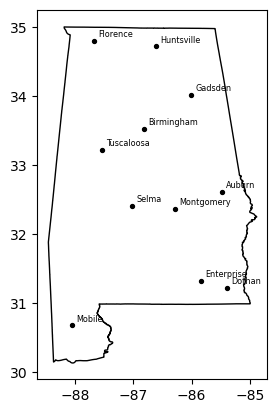

In [54]:
base = AL_reproj.plot(color='white', edgecolor='black')
ax = AL_pop_places.plot(ax=base, marker='o', color='black', markersize=8)

for x, y, label in zip(AL_pop_places.geometry.x, AL_pop_places.geometry.y, AL_pop_places.NAME_left):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points", fontsize = "xx-small")